# CDNOD causal discovery with city regimes

This notebook consumes the outputs of `00_master_feature_creator.ipynb` and runs **CDNOD separately at delivery level and batch level**.

- Regime/domain selector: `city` (`Shanghai`, `Hangzhou`, `Chongqing`)
- Delivery target: `eta_mins`
- Batch target: `eta_mean`
- Candidate variables are restricted to the requested causal families: batch size, spatial dispersion, temporal-slack proxies, merchant concentration, and courier workload state.
- Bootstrap stability is used to retain only stable direct causes and stable directed ancestors of delay.

> CDNOD identifies distribution shifts associated with the city index. City is supplied as the special context variable and is not treated as an ordinary operational feature.

## Interpretation guardrails

 This notebook uses leakage-safe pre-delivery workload state (`courier_eta_ewm` and recent GPS motion) and automatically prefers an explicit workload column if one is present in a future export.

`typecode_cb` is the available merchant/type concentration proxy. At batch level its mean is used. Temporal slack is proxied by receipt-time cyclic variables and dispatch position; no promised-deadline field exists in the master output.

In [1]:
# Run once in a fresh Colab/runtime.
%pip install -q causal-learn pyarrow pandas numpy scipy scikit-learn networkx matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.5/245.5 kB 6.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [26]:
from pathlib import Path
import inspect
import json
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from causallearn.search.ConstraintBased.CDNOD import cdnod

warnings.filterwarnings('ignore', category=RuntimeWarning)
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Master notebook output directory
DATA_DIR = Path('/content/drive/MyDrive/ml/CORRECTEDv3')
OUTPUT_DIR = DATA_DIR / 'causal_graphs' / 'cdnod'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CITY_ORDER = ['Shanghai', 'Hangzhou', 'Chongqing']
CITY_CODE = {city: i for i, city in enumerate(CITY_ORDER)}

ALPHA = 0.01
N_BOOTSTRAPS = 100
STABILITY_THRESHOLD = 0.45
MAX_ANCESTOR_DEPTH = 3
MAX_ROWS_PER_CITY = 25000
MIN_COMPLETE_ROWS = 500

print('CDNOD signature:', inspect.signature(cdnod))
print('Output directory:', OUTPUT_DIR)
print(f'Stability Threshold set to: {STABILITY_THRESHOLD}')

CDNOD signature: (data: numpy.ndarray, c_indx: numpy.ndarray, alpha: float = 0.05, indep_test: str = 'fisherz', stable: bool = True, uc_rule: int = 0, uc_priority: int = 2, mvcdnod: bool = False, correction_name: str = 'MV_Crtn_Fisher_Z', background_knowledge: Optional[causallearn.utils.PCUtils.BackgroundKnowledge.BackgroundKnowledge] = None, verbose: bool = False, show_progress: bool = True, **kwargs) -> causallearn.graph.GraphClass.CausalGraph
Output directory: /content/drive/MyDrive/ml/CORRECTEDv3/causal_graphs/cdnod
Stability Threshold set to: 0.45


## Restricted causal feature contract

Aliases make the notebook compatible with both full v4 delivery features and filtered/aggregated master outputs. Only one available source is selected for each named concept.

In [4]:
DELIVERY_CONCEPTS = {
    # Batch size / queue position
    'batch_size': ['batch_size'],
    'dispatch_position': ['batch_rank_dispatch', 'batch_rank_capped'],

    # Spatial dispersion / route geometry
    'spatial_dispersion': ['distance_to_batch_centroid', 'spatial_congestion_norm'],
    'route_distance': ['pickup_destination_distance'],
    'remaining_haul': ['remaining_haul_distance'],

    # Temporal slack / demand-window proxies
    'receipt_hour_sin': ['hour_sin'],
    'receipt_hour_cos': ['hour_cos'],
    'holiday_pressure': ['is_holiday', 'is_weekend'],

    # Merchant concentration proxy
    'merchant_concentration': ['typecode_cb'],

    # Courier workload / operational state (all measured before delivery)
    'courier_workload': ['active_queue_at_receipt', 'workload_causal', 'courier_local_load', 'courier_eta_ewm'],
    'recent_speed': ['speed_mean_15m', 'speed_mean'],
    'recent_motion': ['distance_travelled_15m', 'distance_travelled'],
}

BATCH_CONCEPTS = {
    'batch_size': ['batch_size'],
    'spatial_dispersion': ['batch_grid_cells_unique', 'spatial_congestion_daily_std', 'spatial_congestion_norm_std'],
    'route_distance': ['pickup_destination_distance_mean'],
    'remaining_haul': ['remaining_haul_distance_mean'],
    'receipt_hour_sin': ['hour_sin'],
    'receipt_hour_cos': ['hour_cos'],
    'holiday_pressure': ['is_holiday', 'is_weekend'],
    'merchant_concentration': ['typecode_cb_mean'],
    'courier_workload': ['active_queue_at_receipt', 'workload_causal', 'courier_local_load', 'courier_eta_ewm'],
    'recent_speed': ['speed_mean_15m_mean', 'speed_mean_mean'],
    'recent_motion': ['distance_travelled_15m_mean', 'distance_travelled_mean'],
}

TARGETS = {'delivery': 'eta_mins', 'batch': 'eta_mean'}

In [8]:
def _first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None


def load_three_city_level(level, data_dir=DATA_DIR):
    """Load master outputs and guarantee a city column."""
    frames, used_paths = [], []

    if level == 'delivery':
        combined = _first_existing([
            data_dir / 'all_cities_delivery_features_v4.parquet',
            data_dir / 'all_cities_v4_filtered.parquet',
        ])
        if combined is not None:
            df = pd.read_parquet(combined)
            if 'city' in df.columns:
                return df, [combined]

        for city in CITY_ORDER:
            slug = city.lower()
            path = _first_existing([
                data_dir / f'delivery_features_{slug}.parquet',
                data_dir / f'delivery_lvl_{slug}_v4.parquet',
            ])
            if path is None:
                raise FileNotFoundError(f'No delivery master output found for {city}')
            part = pd.read_parquet(path)
            part['city'] = city
            frames.append(part)
            used_paths.append(path)

    elif level == 'batch':
        combined = _first_existing([data_dir / 'batch_aggregated_v4.parquet'])
        if combined is not None:
            df = pd.read_parquet(combined)
            if 'city' in df.columns and df['city'].notna().all():
                return df, [combined]

        for city in CITY_ORDER:
            path = data_dir / f'batch_scm_{city.lower()}.parquet'
            if not path.exists():
                raise FileNotFoundError(f'No batch master output found for {city}')
            part = pd.read_parquet(path)
            part['city'] = city
            frames.append(part)
            used_paths.append(path)
    else:
        raise ValueError("level must be 'delivery' or 'batch'")

    return pd.concat(frames, ignore_index=True, sort=False), used_paths


for level in ('delivery',):
    preview, paths = load_three_city_level(level)
    print(f'{level:8s}: {preview.shape} | cities={preview.city.value_counts().to_dict()}')
    print('  sources:', [str(p) for p in paths])

delivery: (100163, 68) | cities={'Hangzhou': 40348, 'Shanghai': 34480, 'Chongqing': 25335}
  sources: ['/content/drive/MyDrive/ml/CORRECTEDv3/delivery_features_shanghai.parquet', '/content/drive/MyDrive/ml/CORRECTEDv3/delivery_features_hangzhou.parquet', '/content/drive/MyDrive/ml/CORRECTEDv3/delivery_features_chongqing.parquet']


In [9]:
def select_concepts(df, concept_map, target):
    """Choose the first available non-degenerate source for each concept."""
    selected = {}
    out = pd.DataFrame(index=df.index)

    for concept, aliases in concept_map.items():
        for source in aliases:
            if source in df.columns:
                values = pd.to_numeric(df[source], errors='coerce')
                if values.notna().sum() > 0 and values.nunique(dropna=True) > 1:
                    out[concept] = values
                    selected[concept] = source
                    break

    if target not in df.columns:
        raise KeyError(f'Missing target {target!r}')
    out[target] = pd.to_numeric(df[target], errors='coerce')
    out['city'] = df['city'].astype(str)
    return out, selected


def prepare_cdnod_data(level, max_rows_per_city=MAX_ROWS_PER_CITY):
    raw, paths = load_three_city_level(level)
    raw = raw[raw['city'].isin(CITY_ORDER)].copy()
    concept_map = DELIVERY_CONCEPTS if level == 'delivery' else BATCH_CONCEPTS
    target = TARGETS[level]
    model_df, selected = select_concepts(raw, concept_map, target)

    # Median imputation is performed within city so city-level shifts are not erased.
    feature_cols = [c for c in model_df.columns if c not in {'city', target}]
    for col in feature_cols + [target]:
        model_df[col] = model_df.groupby('city')[col].transform(lambda s: s.fillna(s.median()))
        model_df[col] = model_df[col].replace([np.inf, -np.inf], np.nan)
        model_df[col] = model_df[col].fillna(model_df[col].median())

    model_df = model_df.dropna(subset=[target])
    sampled = []
    for city in CITY_ORDER:
        part = model_df[model_df.city == city]
        if len(part) > max_rows_per_city:
            part = part.sample(max_rows_per_city, random_state=RANDOM_SEED)
        sampled.append(part)
    model_df = pd.concat(sampled, ignore_index=True)

    if len(model_df) < MIN_COMPLETE_ROWS:
        raise ValueError(f'Only {len(model_df)} usable rows for {level}')

    # Operational variables are standardized; city remains a separate domain index.
    variable_names = feature_cols + [target]
    X = StandardScaler().fit_transform(model_df[variable_names].astype(float))
    c_indx = model_df['city'].map(CITY_CODE).to_numpy(dtype=float).reshape(-1, 1)

    print(f'\n{level.upper()} selected sources:')
    for concept, source in selected.items():
        print(f'  {concept:24s} <- {source}')
    print('  target                  <-', target)
    print('  rows by city:', model_df.city.value_counts().to_dict())
    return model_df, X, c_indx, variable_names, selected, paths

## CDNOD runner and graph extraction

The wrapper filters keyword arguments against the installed `causal-learn` signature. Graph endpoint conventions follow causal-learn: `-1` is a tail, `1` an arrowhead, and `2` a circle.

In [24]:
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode

def run_cdnod(X, c_indx, alpha=ALPHA, show_progress=False, variable_names=None):
    # Create node objects for background knowledge mapping
    # In CDNOD, nodes = variables in X + context variable
    num_vars = X.shape[1] + 1
    nodes = [GraphNode(f'node{i}') for i in range(num_vars)]

    bk = BackgroundKnowledge()
    if variable_names is not None:
        # target_idx is the last operational column index (eta_mins)
        target_node = nodes[len(variable_names) - 1]
        # city_idx is the very last node index (city context)
        city_node = nodes[len(variable_names)]

        for i in range(len(variable_names) - 1):
            # Forbid the target from causing any operational features
            bk.add_forbidden_by_node(target_node, nodes[i])
            # Forbid operational features from causing city_context
            bk.add_forbidden_by_node(nodes[i], city_node)

    requested = {
        'alpha': alpha,
        'indep_test': 'fisherz',
        'stable': True,
        'uc_rule': 0,
        'uc_priority': 2,
        'show_progress': show_progress,
        'background_knowledge': bk
    }
    supported = inspect.signature(cdnod).parameters
    kwargs = {k: v for k, v in requested.items() if k in supported}
    return cdnod(X, c_indx, **kwargs)

def graph_matrix(cg):
    graph_obj = getattr(cg, 'G', cg)
    matrix = getattr(graph_obj, 'graph', None)
    if matrix is None:
        raise AttributeError('Could not locate causal-learn graph matrix')
    return np.asarray(matrix)

def endpoint_edge(matrix, i, j):
    a, b = int(matrix[i, j]), int(matrix[j, i])
    if a == 0 and b == 0:
        return None
    if a == -1 and b == 1:
        return 'i_to_j'
    if a == 1 and b == -1:
        return 'j_to_i'
    return 'ambiguous'

def extract_edges(cg, variable_names):
    matrix = graph_matrix(cg)
    names = list(variable_names)
    if matrix.shape[0] == len(names) + 1:
        names.append('city_context')
    rows = []
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            kind = endpoint_edge(matrix, i, j)
            if kind == 'i_to_j':
                rows.append((names[i], names[j], 'directed'))
            elif kind == 'j_to_i':
                rows.append((names[j], names[i], 'directed'))
            elif kind == 'ambiguous':
                rows.append((names[i], names[j], 'ambiguous'))
    return pd.DataFrame(rows, columns=['source', 'target', 'edge_type']), names

In [17]:
def stratified_bootstrap_indices(city_labels, rng):
    idx = []
    city_labels = np.asarray(city_labels)
    for city in CITY_ORDER:
        city_idx = np.flatnonzero(city_labels == city)
        idx.extend(rng.choice(city_idx, size=len(city_idx), replace=True))
    return np.asarray(idx, dtype=int)

def bootstrap_cdnod(X, c_indx, city_labels, variable_names, n_bootstraps=N_BOOTSTRAPS):
    records = []
    successful_bootstraps = 0
    local_rng = np.random.default_rng(RANDOM_SEED)

    for b in range(n_bootstraps):
        idx = stratified_bootstrap_indices(city_labels, local_rng)
        try:
            # Pass variable_names to apply background knowledge constraints
            cg_b = run_cdnod(X[idx], c_indx[idx], show_progress=False, variable_names=variable_names)
            edges_b, _ = extract_edges(cg_b, variable_names)
            successful_bootstraps += 1
            for row in edges_b.itertuples(index=False):
                pair = tuple(sorted((row.source, row.target)))
                records.append({
                    'bootstrap': b,
                    'node_a': pair[0],
                    'node_b': pair[1],
                    'source': row.source,
                    'target': row.target,
                    'edge_type': row.edge_type,
                })
        except Exception as exc:
            print(f'Bootstrap {b} failed: {exc}')

        if (b + 1) % 10 == 0 or b == n_bootstraps - 1:
            print(f'  completed {b + 1}/{n_bootstraps} bootstraps')

    rec = pd.DataFrame(records)
    if rec.empty: return pd.DataFrame()
    completed = max(successful_bootstraps, 1)
    adjacency = rec.groupby(['node_a', 'node_b']).bootstrap.nunique().div(completed).rename('adjacency_stability').reset_index()
    directed = rec[rec.edge_type == 'directed']
    if directed.empty:
        adjacency['best_source'], adjacency['best_target'], adjacency['direction_stability'] = None, None, 0.0
        return adjacency
    direction_counts = directed.groupby(['node_a', 'node_b', 'source', 'target']).bootstrap.nunique().rename('directed_count').reset_index().sort_values('directed_count', ascending=False).drop_duplicates(['node_a', 'node_b'])
    result = adjacency.merge(direction_counts, on=['node_a', 'node_b'], how='left')
    result['direction_stability'] = result['directed_count'].fillna(0) / completed
    return result.rename(columns={'source': 'best_source', 'target': 'best_target'}).drop(columns=['directed_count'])

In [12]:
def select_delay_ancestors(stability, target, threshold=STABILITY_THRESHOLD, max_depth=MAX_ANCESTOR_DEPTH):
    """Keep stable directed parents/ancestors of delay; report stable ambiguous neighbors separately."""
    stable = stability[stability.adjacency_stability >= threshold].copy()
    directed = stable[
        stable.best_source.notna()
        & (stable.direction_stability >= threshold)
    ].copy()

    graph = nx.DiGraph()
    graph.add_edges_from(directed[['best_source', 'best_target']].itertuples(index=False, name=None))

    kept = {target}
    direct_parents = set(graph.predecessors(target)) if target in graph else set()
    kept.update(direct_parents)

    frontier = set(direct_parents)
    for _ in range(max_depth - 1):
        next_frontier = set()
        for node in frontier:
            next_frontier.update(graph.predecessors(node))
        next_frontier -= kept
        kept.update(next_frontier)
        frontier = next_frontier
        if not frontier:
            break

    ambiguous_neighbors = set()
    for row in stable.itertuples(index=False):
        if target in {row.node_a, row.node_b} and row.direction_stability < threshold:
            ambiguous_neighbors.add(row.node_b if row.node_a == target else row.node_a)

    kept.discard('city_context')
    direct_parents.discard('city_context')
    return sorted(kept), sorted(direct_parents), sorted(ambiguous_neighbors), directed


def plot_stable_graph(directed, kept, target, title):
    sub = directed[
        directed.best_source.isin(kept + ['city_context'])
        & directed.best_target.isin(kept + ['city_context'])
    ]
    G = nx.DiGraph()
    for row in sub.itertuples(index=False):
        G.add_edge(row.best_source, row.best_target, weight=row.direction_stability)
    if not G.nodes:
        print('No stable directed delay-ancestor graph at this threshold.')
        return

    pos = nx.spring_layout(G, seed=RANDOM_SEED, k=1.2)
    colors = ['tomato' if n == target else ('gold' if n == 'city_context' else 'skyblue') for n in G.nodes]
    widths = [1 + 4 * G[u][v]['weight'] for u, v in G.edges]
    plt.figure(figsize=(11, 7))
    nx.draw_networkx(G, pos, node_color=colors, node_size=2300, width=widths, arrowsize=22, font_size=9)
    labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=8)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [18]:
def run_level_pipeline(level):
    model_df, X, c_indx, variable_names, selected, paths = prepare_cdnod_data(level)
    target = TARGETS[level]

    print(f'\nRunning full-sample CDNOD for {level} level...')
    # Pass variable_names to enable background knowledge constraints
    cg = run_cdnod(X, c_indx, show_progress=True, variable_names=variable_names)
    full_edges, graph_names = extract_edges(cg, variable_names)
    display(full_edges)

    print(f'\nEstimating edge stability with {N_BOOTSTRAPS} stratified bootstraps...')
    stability = bootstrap_cdnod(X, c_indx, model_df.city.to_numpy(), variable_names)
    stability = stability.sort_values(['adjacency_stability', 'direction_stability'], ascending=False)

    kept, direct_parents, ambiguous_neighbors, stable_directed = select_delay_ancestors(stability, target)
    ancestor_features = [c for c in kept if c != target]

    print('\nStable direct causes/parents of delay:', direct_parents or 'none oriented')
    print('Stable ancestors retained:', ancestor_features or 'none oriented')
    print('Stable but unoriented delay neighbors:', ambiguous_neighbors or 'none')

    reduced = model_df[['city'] + kept].copy()
    reduced_path = OUTPUT_DIR / f'{level}_cdnod_delay_ancestors.parquet'
    edges_path = OUTPUT_DIR / f'{level}_cdnod_edge_stability.csv'
    metadata_path = OUTPUT_DIR / f'{level}_cdnod_metadata.json'
    reduced.to_parquet(reduced_path, index=False)
    stability.to_csv(edges_path, index=False)

    metadata = {
        'level': level,
        'target': target,
        'cities': CITY_ORDER,
        'alpha': ALPHA,
        'n_bootstraps': N_BOOTSTRAPS,
        'stability_threshold': STABILITY_THRESHOLD,
        'max_ancestor_depth': MAX_ANCESTOR_DEPTH,
        'selected_source_columns': selected,
        'direct_parents': direct_parents,
        'retained_ancestors': ancestor_features,
        'ambiguous_delay_neighbors': ambiguous_neighbors,
        'input_paths': [str(p) for p in paths],
    }
    metadata_path.write_text(json.dumps(metadata, indent=2))

    print('\nSaved:')
    print(' ', reduced_path)
    print(' ', edges_path)
    print(' ', metadata_path)
    display(stability.head(25))
    plot_stable_graph(stable_directed, kept, target, f'CDNOD stable delay ancestors — {level.title()} level')

    return {
        'model_df': model_df,
        'causal_graph': cg,
        'full_edges': full_edges,
        'stability': stability,
        'kept': kept,
        'direct_parents': direct_parents,
        'ambiguous_neighbors': ambiguous_neighbors,
        'reduced': reduced,
        'metadata': metadata,
    }

## 1. Delivery-level CDNOD

Each row is an order. The resulting reduced parquet contains city, delivery delay, and only stable direct parents/ancestors of delivery delay.


DELIVERY selected sources:
  batch_size               <- batch_size
  dispatch_position        <- batch_rank_dispatch
  spatial_dispersion       <- distance_to_batch_centroid
  route_distance           <- pickup_destination_distance
  remaining_haul           <- remaining_haul_distance
  receipt_hour_sin         <- hour_sin
  receipt_hour_cos         <- hour_cos
  holiday_pressure         <- is_weekend
  merchant_concentration   <- typecode_cb
  courier_workload         <- courier_eta_ewm
  recent_speed             <- speed_mean_15m
  recent_motion            <- distance_travelled_15m
  target                  <- eta_mins
  rows by city: {'Shanghai': 25000, 'Hangzhou': 25000, 'Chongqing': 25000}

Running full-sample CDNOD for delivery level...


  0%|          | 0/14 [00:00<?, ?it/s]

,source,target,edge_type
0,dispatch_position,batch_size,directed
1,spatial_dispersion,batch_size,directed
2,remaining_haul,batch_size,directed
3,receipt_hour_cos,batch_size,directed
4,recent_motion,batch_size,directed
5,eta_mins,batch_size,directed
6,city_context,batch_size,directed
7,dispatch_position,spatial_dispersion,directed
8,route_distance,spatial_dispersion,directed
9,spatial_dispersion,courier_workload,directed



Estimating edge stability with 100 stratified bootstraps...


  0%|          | 0/14 [00:00<?, ?it/s]

...

  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/14 [00:00<?, ?it/s]

  completed 100/100 bootstraps

Stable direct causes/parents of delay: none oriented
Stable ancestors retained: none oriented
Stable but unoriented delay neighbors: ['courier_workload']

Saved:
  /content/drive/MyDrive/ml/CORRECTEDv3/causal_graphs/cdnod/delivery_cdnod_delay_ancestors.parquet
  /content/drive/MyDrive/ml/CORRECTEDv3/causal_graphs/cdnod/delivery_cdnod_edge_stability.csv
  /content/drive/MyDrive/ml/CORRECTEDv3/causal_graphs/cdnod/delivery_cdnod_metadata.json


,node_a,node_b,adjacency_stability,best_source,best_target,direction_stability
0,batch_size,city_context,1.0,city_context,batch_size,1.00
3,batch_size,eta_mins,1.0,eta_mins,batch_size,1.00
5,batch_size,receipt_hour_cos,1.0,receipt_hour_cos,batch_size,1.00
9,city_context,courier_workload,1.0,city_context,courier_workload,1.00
10,city_context,eta_mins,1.0,city_context,eta_mins,1.00
11,city_context,merchant_concentration,1.0,city_context,merchant_concentration,1.00
15,city_context,remaining_haul,1.0,city_context,remaining_haul,1.00
16,city_context,route_distance,1.0,city_context,route_distance,1.00
22,courier_workload,route_distance,1.0,courier_workload,route_distance,1.00
43,merchant_concentration,receipt_hour_cos,1.0,merchant_concentration,receipt_hour_cos,1.00


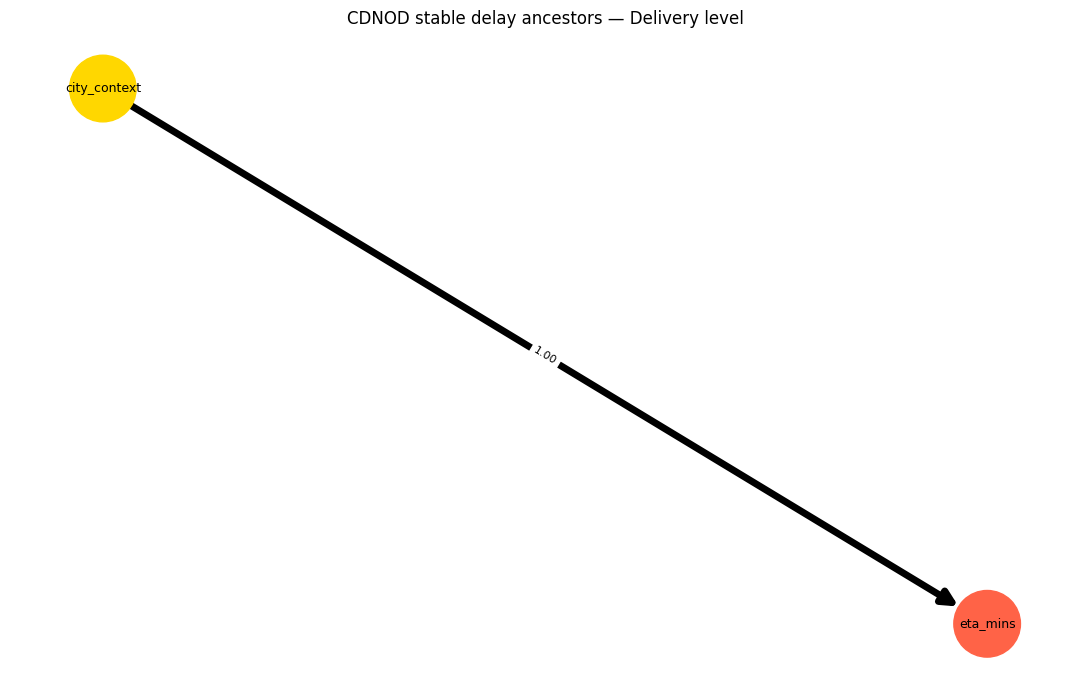

In [27]:
delivery_results = run_level_pipeline('delivery')

In [15]:
print('--- Top Edge Stability Scores ---')
if 'delivery_results' in globals():
    display(delivery_results['stability'].sort_values('adjacency_stability', ascending=False).head(10))
else:
    print('delivery_results not found. Please ensure the delivery-run cell finished executing.')

--- Top Edge Stability Scores ---


,node_a,node_b,adjacency_stability,best_source,best_target,direction_stability
0,batch_size,city_context,1.0,city_context,batch_size,1.0
3,batch_size,eta_mins,1.0,eta_mins,batch_size,1.0
5,batch_size,receipt_hour_cos,1.0,receipt_hour_cos,batch_size,1.0
9,city_context,courier_workload,1.0,city_context,courier_workload,1.0
10,city_context,eta_mins,1.0,city_context,eta_mins,1.0
11,city_context,merchant_concentration,1.0,city_context,merchant_concentration,1.0
15,city_context,remaining_haul,1.0,city_context,remaining_haul,1.0
16,city_context,route_distance,1.0,city_context,route_distance,1.0
22,courier_workload,route_distance,1.0,courier_workload,route_distance,1.0
43,merchant_concentration,receipt_hour_cos,1.0,merchant_concentration,receipt_hour_cos,1.0


## 2. Batch-level CDNOD

Each row is a courier batch. The target is mean batch delay (`eta_mean`), and dispersion/workload variables use batch-level aggregates from the master notebook.

In [7]:
# batch_results = run_level_pipeline('batch')

## Cross-level comparison

Features retained at both levels are the most portable causal candidates. Level-specific ancestors may reflect within-order routing effects versus batch composition effects.

In [ ]:
delivery_ancestors = set(delivery_results['kept']) - {TARGETS['delivery']}
batch_ancestors = set(batch_results['kept']) - {TARGETS['batch']}

comparison = pd.DataFrame({
    'feature': sorted(delivery_ancestors | batch_ancestors),
}).assign(
    delivery_ancestor=lambda d: d.feature.isin(delivery_ancestors),
    batch_ancestor=lambda d: d.feature.isin(batch_ancestors),
    retained_at_both=lambda d: d.delivery_ancestor & d.batch_ancestor,
)

comparison_path = OUTPUT_DIR / 'cdnod_delivery_batch_ancestor_comparison.csv'
comparison.to_csv(comparison_path, index=False)
display(comparison)
print('Saved:', comparison_path)

## Reading the outputs

- `*_cdnod_delay_ancestors.parquet`: final reduced modeling table.
- `*_cdnod_edge_stability.csv`: bootstrap adjacency and direction frequencies.
- `*_cdnod_metadata.json`: selected source columns, thresholds, direct parents, ancestors, and ambiguous delay neighbors.
- A stable `city_context → feature` edge means that mechanism/distribution changes across cities; it is not itself an operational intervention.
- Stable but unoriented neighbors are reported, but deliberately excluded from the strict ancestor table. Lower `STABILITY_THRESHOLD` only as a sensitivity analysis.